c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\MSI\anaconda3\envs\my-project\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


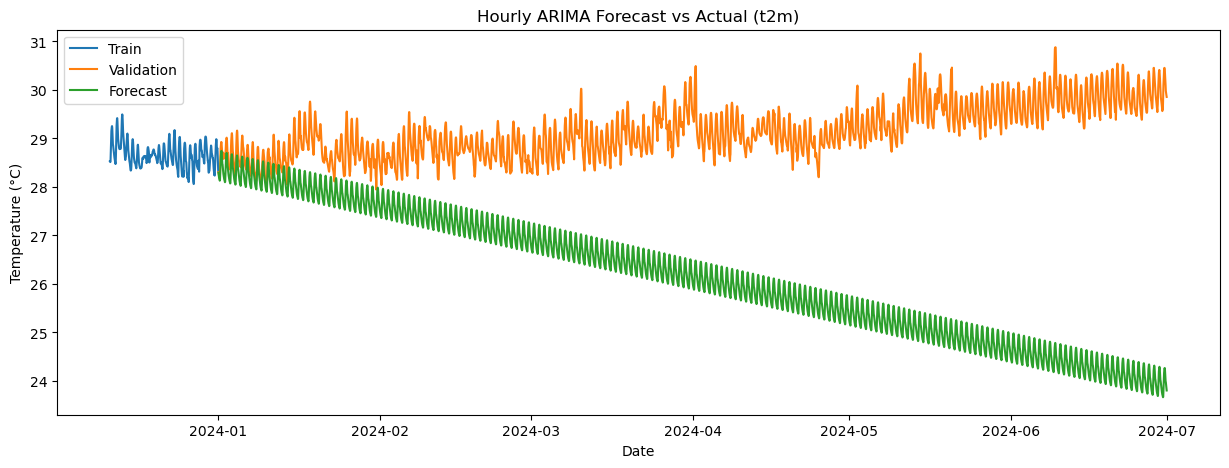

MAE: 2.9968413380915475
RMSE: 3.4529668835111726


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df = df.set_index('valid_time')

# ARIMA for t2m
train = df.loc[:'2023-12-31']['t2m']
val = df.loc['2024-01-01':'2024-06-30']['t2m']

model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,24))
model_fit = model.fit(disp=False)

forecast = model_fit.predict(start=val.index[0], end=val.index[-1], dynamic=False)

plt.figure(figsize=(15,5))
plt.plot(train[-500:], label='Train')
plt.plot(val, label='Validation')
plt.plot(forecast, label='Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Hourly ARIMA Forecast vs Actual (t2m)')
plt.legend()
plt.show()

mae = mean_absolute_error(val, forecast)
rmse = np.sqrt(mean_squared_error(val, forecast))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
